In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('seamless_transactions_clean.xlsx')
df['Total_Price_INR'] = df['Unit_Price_INR'] * df['Quantity']

# Verify it worked
print(df[['Product_Name', 'Unit_Price_INR', 'Quantity', 'Total_Price_INR']].head(10))
print("\nTotal Revenue: ₹", df['Total_Price_INR'].sum())

  Product_Name  Unit_Price_INR  Quantity  Total_Price_INR
0         Rice              50         3              150
1         Milk              60         2              120
2         Eggs              80         1               80
3        Bread              40         2               80
4         Rice              50         2              100
5         Eggs              80         2              160
6          Oil             120         2              240
7         Milk              60         2              120
8         Rice              50         1               50
9        Bread              40         2               80

Total Revenue: ₹ 4600


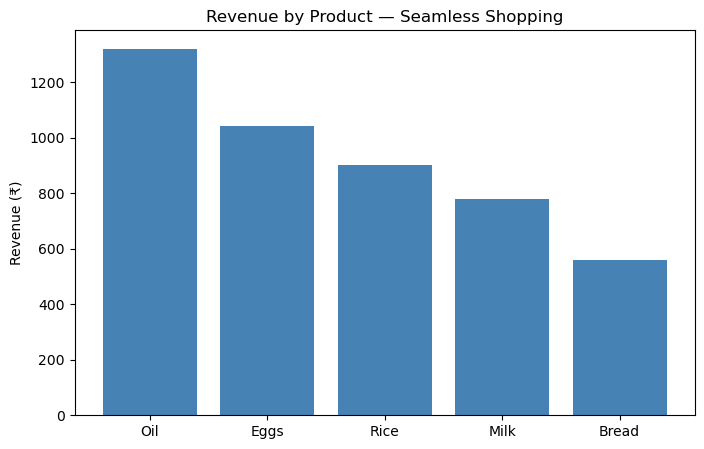

In [10]:
revenue = df.groupby('Product_Name')['Total_Price_INR'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
plt.bar(revenue.index, revenue.values, color='steelblue')
plt.title('Revenue by Product — Seamless Shopping')
plt.ylabel('Revenue (₹)')
plt.savefig('chart1_revenue.png', bbox_inches='tight')
plt.show()

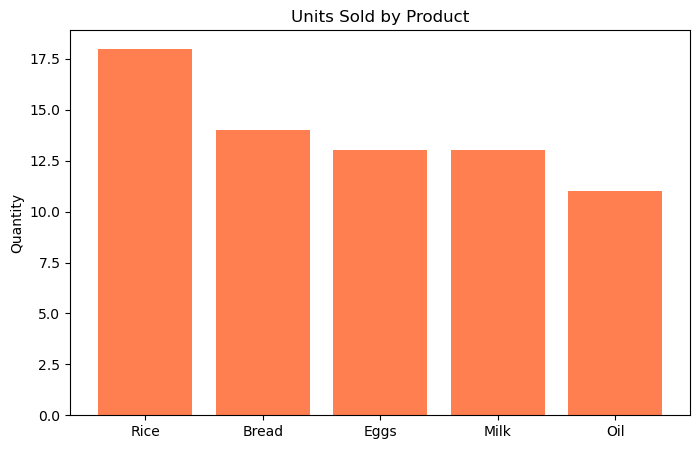

In [11]:
qty = df.groupby('Product_Name')['Quantity'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
plt.bar(qty.index, qty.values, color='coral')
plt.title('Units Sold by Product')
plt.ylabel('Quantity')
plt.savefig('chart2_quantity.png', bbox_inches='tight')
plt.show()

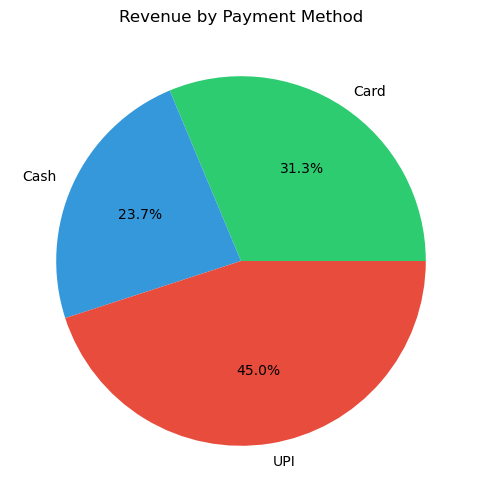

In [12]:
# Chart 3 — Payment Method Distribution
pay = df.groupby('Payment_Method')['Total_Price_INR'].sum().dropna()
pay = pay[pay > 0]  # Remove any zeros

plt.figure(figsize=(6,6))
plt.pie(pay.values, labels=pay.index, autopct='%1.1f%%',
        colors=['#2ECC71','#3498DB','#E74C3C'])
plt.title('Revenue by Payment Method')
plt.savefig('chart3_payment.png', bbox_inches='tight')
plt.show()

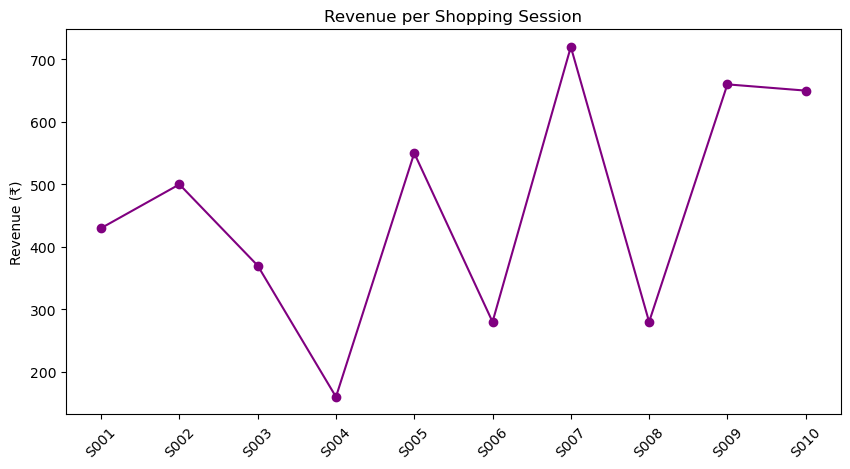

In [13]:
session_rev = df.groupby('Session_ID')['Total_Price_INR'].sum()
plt.figure(figsize=(10,5))
plt.plot(session_rev.index, session_rev.values, marker='o', color='purple')
plt.title('Revenue per Shopping Session')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=45)
plt.savefig('chart4_sessions.png', bbox_inches='tight')
plt.show()

## Business Insights
After analysis write these 4 insights:

1)Oil generates highest revenue — ₹1,320 (28.7% of total) despite being 3rd in quantity — high unit price drives revenue
2)Rice is most frequently purchased — 18 units across all 10 sessions — a staple that should always be stocked
3)UPI dominates payments — 45% of revenue via UPI — digital payment infrastructure is critical
4)Average cart value is ₹460 — customers spend moderately per visit suggesting opportunity for upselling

